# VQE Configuration Sweep

**Thomas Griffiths** — Quantum Computing Course (PH10110), University of Edinburgh

This notebook runs the systematic sweep that `Regression.ipynb` later trains
on: every combination of ansatz, repetitions, and optimizer is run across the
full $J_z \in [-3, 3]$ range, first noiselessly at a fixed 8 qubits, then with
a realistic noise model across multiple qubit counts (4, 6, 8). This is a
script-style notebook rather than a narrative one — most cells are long-running
batch jobs rather than step-by-step exploration; see `Introduction.ipynb` for
the narrative walkthrough of the same physics.

## This notebook covers
1. **Noiseless sweep** — 3 ansatz (EfficientSU2, RealAmplitudes, N-Local) × 2
   repetition counts × 4 optimizers (SPSA, COBYLA, NFT, QNSPSA) = 24 configs,
   each run across 25 $J_z$ values, at a fixed 8 qubits.
2. **Noisy, multi-qubit sweep** — the same 24 configs repeated at qubit counts
   4, 6, and 8 (72 configs total), using a `GenericBackendV2`-derived noise
   model (or a real IBM backend's noise model, if available), parallelized
   across threads for speed.
3. **Results export** — the multi-qubit sweep results are flattened into a
   per-(config, $J_z$) row DataFrame and saved to CSV for downstream use in
   `Regression.ipynb`.
4. **Summary plots** — best-performing configuration per ansatz, plus
   convergence curves at representative $J_z$ values.

## Requirements & setup
Requires a `token.json` file (`{"api_key": "..."}`) with an IBM Quantum API
key for cell 1 to authenticate — needed even for the noiseless/simulated
sweep cells below since `QiskitRuntimeService` is imported, though no real
hardware time is consumed by this notebook (see `IBM.ipynb` for the actual
hardware runs). Full sweep takes on the order of tens of minutes locally
(noiseless ~15 minutes; the noisy multi-qubit sweep is longer, run with 4
worker threads).

## Output
Saves `Results/multiqubit_sweep_results.csv` — `Results/` is the fixed,
shared output directory used across this project (`IBM.ipynb` writes its
hardware-run data and plots there too), and is what `Regression.ipynb` reads
from in turn.

In [1]:
import argparse
import json
import time
import traceback
from pathlib import Path
import threading

import numpy as np
from scipy.linalg import eigh
import pandas as pd
import matplotlib.pyplot as plt

from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import efficient_su2, real_amplitudes, n_local
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms import VQE
from qiskit_algorithms.utils import algorithm_globals
from qiskit_algorithms.optimizers import (
    SPSA, COBYLA, NFT, QNSPSA
)
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_algorithms.state_fidelities import ComputeUncompute
from qiskit.primitives import StatevectorSampler
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit.providers.fake_provider import GenericBackendV2

from multiprocessing.pool import ThreadPool

In [2]:
with open("token.json", "r") as f:
    token = json.load(f)

QiskitRuntimeService.save_account(
    channel = "ibm_quantum_platform",
    token = token["api_key"],
    overwrite = True)

In [3]:
seed = 64
algorithm_globals.random_seed = seed
np.random.seed(seed)

# ------ Hamiltonian -------- #

def heisenberg_hamiltonian(n_qubits, Jz = 1.0):
    terms = []
    for i in range(n_qubits -1):
        for pauli_char in ['X', 'Y']:
            p = ['I'] * n_qubits
            p[i] = pauli_char
            p[i+1] = pauli_char
            # join(p) converts list of characters to string, e.g. ['X', 'X', 'I'] -> 'XXI'
            terms.append((''.join(p), 1.0)) 
        pz = ['I'] * n_qubits
        pz[i] = 'Z'
        pz[i+1] = 'Z'
        terms.append((''.join(pz), Jz))
    return SparsePauliOp.from_list(terms)

# ------ Order Parameter -------- #

def s_pi_operator(n_qubits):
    terms = []
    for i in range(n_qubits):
        for j in range(i+1, n_qubits):
            p = ['I'] * n_qubits
            p[i] = 'Z'
            p[j] = 'Z'
            coeff = ((-1)**(i-j))  / n_qubits
            terms.append((''.join(p), coeff))
    return SparsePauliOp.from_list(terms)

# ------ Exact Ground State -------- #

def exact_ground_state(hamiltonian):
    h_mat = np.array(hamiltonian.to_matrix())
    eigenvalues, eigenvectors = eigh(h_mat)
    # Returns the exact ground state energy and vector
    return float(eigenvalues[0]), eigenvectors[:, 0] 


# ------ Ansatz Construction ------ #

def construct_ansatz(name, n_qubits, reps, entanglement = "linear"):
    if name == "efficient_su2":
        return efficient_su2(n_qubits, reps=reps, entanglement=entanglement).decompose()
    elif name == "real_amplitudes":
        return real_amplitudes(n_qubits, reps=reps, entanglement=entanglement).decompose()
    elif name == "n_local":
        return n_local(n_qubits, reps=reps, rotation_blocks=["ry", "rz"], entanglement_blocks = "cz").decompose()
    
# ------ Optimizer Construction ------ #

def build_optimizer(name, maxiter, ansatz = None):
    # QNSPSA requires a per-ansatz fiedelity function and its treated as a special case below
    if name == "QNSPSA":
        fidelity = QNSPSA.get_fidelity(ansatz, StatevectorSampler())
        return QNSPSA(fidelity=fidelity, maxiter=maxiter)
    return {
        "SPSA": lambda: SPSA(maxiter=maxiter),
        "COBYLA": lambda: COBYLA(maxiter=maxiter),
        "NFT": lambda: NFT(maxiter=maxiter)
    }[name]()

# ------ Noise Model ------ #

n_qubits = 8
coupling_map = [[0, 1], [1, 2], [2, 3], [3, 4], [4, 5], [5, 6], [6, 7]]

# Builds a noiseless estimator 
noiseless_estimator = StatevectorEstimator()

# ----- Main Sweep Function ------ # (takes around 15 minutes to run for all configs on a local machine)

def run_config_noiseless(ansatz_name, reps, optimizer_name, n_qubits, jz_vals, maxiter):
    ansatz = construct_ansatz(ansatz_name, n_qubits, reps)
    optimizer = build_optimizer(optimizer_name, maxiter, ansatz)
    s_pi_mat = np.array(s_pi_operator(n_qubits).to_matrix()) #  Precompute the S(π) matrix for exact calculations

    # Lists to store convergence data across all Jz values for this config
    all_counts, all_values = [], []
    
    # Callback function to track convergence during VQE optimization
    def callback(eval_count, parameters, mean, std):
        if eval_count == 1:
            all_counts.append([])
            all_values.append([])
        all_counts[-1].append(eval_count)
        all_values[-1].append(mean)

    vqe = VQE(noiseless_estimator, ansatz=ansatz, optimizer=optimizer, callback=callback)


    j_list, e_vqe, e_exact, spi_vqe, spi_exact, wall_time = [], [], [], [], [], []

    opt_params = None

    for jz in jz_vals:
        H = heisenberg_hamiltonian(n_qubits, Jz=jz)

        # Uses warm-start from previous Jz value, which significantly improves convergence
        if opt_params is not None:
            vqe.initial_point = opt_params 

        # Run VQE and time it
        t0 = time.time()
        noiseless_results = vqe.compute_minimum_eigenvalue(H)
        elapsed = time.time() - t0
        opt_params = noiseless_results.optimal_point

        # Calculate S(π) using the optimal parameters from VQE
        sqi_val = float(np.real(noiseless_estimator.run([(ansatz, s_pi_operator(n_qubits), opt_params)]).result()[0].data.evs))

        # Calculate exact ground state energy and S(π) for comparison
        e_gs, psi0 = exact_ground_state(H)
        spi_ex = float(np.real(psi0.conj() @ s_pi_mat @ psi0))

        # Store results
        j_list.append(float(jz))
        e_vqe.append(float(np.real(noiseless_results.eigenvalue)))
        e_exact.append(e_gs)
        spi_vqe.append(sqi_val)
        spi_exact.append(spi_ex)
        wall_time.append(elapsed)

    # Calculate energy errors for the noiseless case
    energy_errors = [v - e for v, e in zip(e_vqe, e_exact)]

    return {
        "ansatz_names": ansatz_name,
        "reps": reps,
        "optimizer": optimizer_name,
        "n_qubits": n_qubits,
        "n_params": ansatz.num_parameters,
        "jz_values": j_list,
        "circuit_depth": ansatz.depth(),
        "E_vqe": e_vqe,
        "E_exact": e_exact,
        "energy_errors": energy_errors,
        "Spi_vqe": spi_vqe,
        "Spi_exact": spi_exact,
        "wall_times": wall_time,
        "mean_abs_error": float(np.mean(np.abs(energy_errors))),
        "max_abs_error": float(np.max(np.abs(energy_errors))),
        "total_time_s": float(np.sum(wall_time)),
        "conv_counts": all_counts,
        "conv_values": all_values,
    }

# ----- Configuration for the sweep ----- #

jz_vals = list(np.arange(-3.0 , 3.0 + 0.125, 0.25))
maxiter = 300

ansatz_names = ["efficient_su2", "real_amplitudes", "n_local"]
reps_options = [1, 2]
optimizer_names = ["SPSA", "COBYLA", "NFT", "QNSPSA"]

configs = [(ans, rep, opt)
            for ans in ansatz_names
            for rep in reps_options
            for opt in optimizer_names]

print(f"Noiseless VQE Sweep: {len(configs)} configs x {len(jz_vals)} Jz values each")
print(f"n_qubits = {n_qubits}, maxiter = {maxiter}\n")

noiseless_sweep_results = []
failed_configs = []

for i, (ans, rep, opt) in enumerate(configs):
    label = f"[{i+1}/{len(configs)}] {ans} | reps={rep} | {opt}"
    print(f"{label} ...", end=" ", flush=True)
    t0 = time.time()
    try:
        noiseless_result = run_config_noiseless(ans, rep, opt, n_qubits, jz_vals, maxiter)
        noiseless_sweep_results.append(noiseless_result)
        print(f"mean|ΔE|={noiseless_result['mean_abs_error']:.4f}, depth={noiseless_result['circuit_depth']}, t={time.time()-t0:.0f}s")
    except Exception as e:
        print(f"FAILED: {e}")
        failed_configs.append({"config": label, "error": str(e), "traceback": traceback.format_exc()})

# ----- Rankings ----- #

noiseless_ranked = sorted(noiseless_sweep_results, key=lambda r: r["mean_abs_error"])
print(f"\n{'Ansatz':<16} {'Reps':<6} {'Optimizer':<10} {'Mean|ΔE|':<12} {'Depth'} ")
print("-" * 55)
for r in noiseless_sweep_results[:5]:
    print('Ansatz   Reps  Optimizer Mean|ΔE|    Depth')
    print(f"{r['ansatz_names']:<16} {r['reps']:<6} {r['optimizer']:<10} {r['mean_abs_error']:<12.5f} {r['circuit_depth']}")

Noiseless VQE Sweep: 24 configs x 25 Jz values each
n_qubits = 8, maxiter = 300

[1/24] efficient_su2 | reps=1 | SPSA ... mean|ΔE|=4.2668, depth=11, t=30s
[2/24] efficient_su2 | reps=1 | COBYLA ... mean|ΔE|=0.8089, depth=11, t=21s
[3/24] efficient_su2 | reps=1 | NFT ... mean|ΔE|=1.0524, depth=11, t=34s
[4/24] efficient_su2 | reps=1 | QNSPSA ... mean|ΔE|=2.9567, depth=11, t=198s
[5/24] efficient_su2 | reps=2 | SPSA ... mean|ΔE|=4.0268, depth=15, t=37s
[6/24] efficient_su2 | reps=2 | COBYLA ... mean|ΔE|=1.9360, depth=15, t=25s
[7/24] efficient_su2 | reps=2 | NFT ... mean|ΔE|=0.8238, depth=15, t=39s
[8/24] efficient_su2 | reps=2 | QNSPSA ... mean|ΔE|=4.9087, depth=15, t=261s
[9/24] real_amplitudes | reps=1 | SPSA ... mean|ΔE|=3.2083, depth=9, t=24s
[10/24] real_amplitudes | reps=1 | COBYLA ... mean|ΔE|=0.5987, depth=9, t=16s
[11/24] real_amplitudes | reps=1 | NFT ... mean|ΔE|=0.8332, depth=9, t=25s
[12/24] real_amplitudes | reps=1 | QNSPSA ... mean|ΔE|=1.3432, depth=9, t=133s
[13/24] real

In [4]:
# ----- Multi-Qubit Noise Model ----- # 
def build_noisy_estimator(n_qubits, seed):
    coupling_map = [[i, i+1] for i in range(n_qubits - 1)]

    # Uses the noise model from a real backend (ibm_fez) - requires IBM account
    # service = QiskitRuntimeService()
    # real_backend = service.backend("ibm_fez")
    # noise_model = NoiseModel.from_backend(real_backend)
    
    # If no IBM account, use this generic noise model
    device = GenericBackendV2(num_qubits=n_qubits, coupling_map=coupling_map, seed=seed)
    noise_model = NoiseModel.from_backend(device)



    # Build the noisy backend simulator
    noisy_estimator = AerEstimator(
        options={
            "default_precision": 1e-2, 
            "backend_options": {
                "method": "density_matrix",        # required for realistic noise simulation
                "coupling_map": coupling_map,
                "noise_model": noise_model,
            }
        }
    )

    return noisy_estimator
# ----- Noisy Config ------ # (warning takes approximately )

def run_config_multiqubit(ansatz_name, reps, optimizer_name, n_qubits, jz_vals, maxiter):
    noisy_estimator = build_noisy_estimator(n_qubits, seed)

    ansatz = construct_ansatz(ansatz_name, n_qubits, reps)
    optimizer = build_optimizer(optimizer_name, maxiter, ansatz)
    s_pi_mat = np.array(s_pi_operator(n_qubits).to_matrix()) #  Precompute the S(π) matrix for exact calculations

    # Lists to store convergence data across all Jz values for this config
    all_counts, all_values = [], []
    
    # Callback function to track convergence during VQE optimization
    def callback(eval_count, parameters, mean, std):
        if eval_count == 1:
            all_counts.append([])
            all_values.append([])
        all_counts[-1].append(eval_count)
        all_values[-1].append(mean)

    vqe = VQE(noisy_estimator, ansatz=ansatz, optimizer=optimizer, callback= callback)

    j_list, e_vqe, e_exact, spi_vqe, spi_exact, wall_time = [], [], [], [], [], []

    opt_params = None

    for jz in jz_vals:
        H = heisenberg_hamiltonian(n_qubits, Jz=jz)

        # Uses warm-start from previous Jz value, which significantly improves convergence
        if opt_params is not None:
            vqe.initial_point = opt_params 

        # Run VQE and time it
        t0 = time.time()
        results = vqe.compute_minimum_eigenvalue(H)
        elapsed = time.time() - t0
        opt_params = results.optimal_point

        # Calculate S(π) using the optimal parameters from VQE
        sqi_val = float(np.real(noisy_estimator.run([(ansatz, s_pi_operator(n_qubits), opt_params)]).result()[0].data.evs))

        # Calculate exact ground state energy and S(π) for comparison
        e_gs, psi0 = exact_ground_state(H)
        spi_ex = float(np.real(psi0.conj() @ s_pi_mat @ psi0))

        # Store results
        j_list.append(float(jz))
        e_vqe.append(float(np.real(results.eigenvalue)))
        e_exact.append(e_gs)
        spi_vqe.append(sqi_val)
        spi_exact.append(spi_ex)
        wall_time.append(elapsed)

    # Calculate energy errors for the noisy case
    energy_errors = [v - e for v, e in zip(e_vqe, e_exact)]

    return {
        "ansatz_names": ansatz_name,
        "reps": reps,
        "optimizer": optimizer_name,
        "n_qubits": n_qubits,
        "n_params": ansatz.num_parameters,
        "jz_values": j_list,
        "circuit_depth": ansatz.depth(),
        "E_vqe": e_vqe,
        "E_exact": e_exact,
        "energy_errors": energy_errors,
        "Spi_vqe": spi_vqe,
        "Spi_exact": spi_exact,
        "wall_times": wall_time,
        "mean_abs_error": float(np.mean(np.abs(energy_errors))),
        "max_abs_error": float(np.max(np.abs(energy_errors))),
        "total_time_s": float(np.sum(wall_time)),
        "conv_counts": all_counts,
        "conv_values": all_values,
    }

# ----- Configuration for the sweep ----- #

jz_vals = list(np.arange(-3.0 , 3.0 + 0.125, 0.25)) # 13 points
maxiter = 300
qubit_counts = [4, 6, 8]

ansatz_names = ["efficient_su2", "real_amplitudes", "n_local"]
reps_options = [1, 2]
optimizer_names = ["SPSA", "COBYLA", "NFT", "QNSPSA"]

configs = [(n, ans, rep, opt)
            for n in qubit_counts
            for ans in ansatz_names
            for rep in reps_options
            for opt in optimizer_names]

print(f"Multi-Qubit VQE Sweep: {len(configs)} configs x {len(jz_vals)} Jz values each")
print(f"Qubit counts: = {qubit_counts}, maxiter = {maxiter}\n")

#----- Wrapper (multithreading for speed up) -----#

counter = 0
counter_lock = threading.Lock()
total = len(configs)

def run_config_wrapper(args):
    global counter
    n, ans, rep, opt = args
    label = f" n={n} | {ans} | reps={rep} | {opt}"
    t0 = time.time()
    try:
        result = run_config_multiqubit(ans, rep, opt, n, jz_vals, maxiter)
        with counter_lock:
            counter += 1
            progress = counter
        print(f"[{progress}/{total}] ✓ n={n} | {ans} | reps={rep} | {opt} | mean|ΔE|={result['mean_abs_error']:.4f}, depth={result['circuit_depth']}, t={time.time()-t0:.0f}s")
        return ("ok", result)
    except Exception as e:
        print(f"{label} ... FAILED: {e}")
        return ("error", {"config": label, "error": str(e), "traceback": traceback.format_exc()})
    
n_workers = 4 # Ran on Macbook Pro with 5 performance cores and 6 efficient cores
with ThreadPool(processes = n_workers) as pool:
        raw_results = pool.map(run_config_wrapper, configs)

multiqubit_results = [r for status, r in raw_results if status == "ok"]
failed_configs = [r for status, r in raw_results if status == "error"]

print(f"\n{len(multiqubit_results)}/{len(configs)} compelted, {len(failed_configs)} failed")

# ----- Rankings ----- #
print(f"\n{'n':<5} {'Ansatz':<16} {'Reps':<6} {'Optimizer':<10} {'Mean|ΔE|':<12} {'Depth'}")
print("-" * 60)

for n in qubit_counts:
    n_results = [r for r in multiqubit_results if r["n_qubits"] == n]
    ranked    = sorted(n_results, key=lambda r: r["mean_abs_error"])
    print(f"\n  n={n}:")
    for r in ranked[:5]:
        print(f"Qubits  Ansatz        Reps   Optimizer  Mean|ΔE|     Depth")
        print(f"  {n:<5} {r['ansatz_names']:<16} {r['reps']:<6} {r['optimizer']:<10} {r['mean_abs_error']:<12.5f} {r['circuit_depth']}")


Multi-Qubit VQE Sweep: 72 configs x 25 Jz values each
Qubit counts: = [4, 6, 8], maxiter = 300

[1/72] ✓ n=4 | efficient_su2 | reps=2 | COBYLA | mean|ΔE|=0.6411, depth=11, t=46s
[2/72] ✓ n=4 | efficient_su2 | reps=1 | SPSA | mean|ΔE|=1.6500, depth=7, t=78s
[3/72] ✓ n=4 | efficient_su2 | reps=1 | COBYLA | mean|ΔE|=0.4584, depth=7, t=32s
[4/72] ✓ n=4 | real_amplitudes | reps=1 | NFT | mean|ΔE|=0.2677, depth=5, t=133s
[5/72] ✓ n=4 | efficient_su2 | reps=2 | NFT | mean|ΔE|=0.3327, depth=11, t=130s
[6/72] ✓ n=4 | efficient_su2 | reps=1 | NFT | mean|ΔE|=0.2965, depth=7, t=117s
[7/72] ✓ n=4 | real_amplitudes | reps=2 | QNSPSA | mean|ΔE|=0.4932, depth=8, t=555s
[8/72] ✓ n=4 | real_amplitudes | reps=1 | QNSPSA | mean|ΔE|=0.3635, depth=5, t=468s
[9/72] ✓ n=4 | n_local | reps=1 | SPSA | mean|ΔE|=2.1042, depth=15, t=68s
[10/72] ✓ n=4 | n_local | reps=1 | COBYLA | mean|ΔE|=1.2715, depth=15, t=30s
[11/72] ✓ n=4 | real_amplitudes | reps=2 | SPSA | mean|ΔE|=1.6450, depth=8, t=75s
[12/72] ✓ n=4 | real_

In [5]:
#----- Save Results ----- # (For DNN analysis)

def results_to_dataframe(sweep_results):
    rows = []
    for r in sweep_results:
        n_jz = len(r["jz_values"])
        for k in range(n_jz):
            rows.append({
                # Config Features (inputs for DNN)
                "ansatz": r["ansatz_names"],
                "reps": r["reps"],
                "optimizer": r["optimizer"],
                "n_qubits": r["n_qubits"],
                "n_params": r["n_params"],
                "circuit_depth": r["circuit_depth"],
                # Per Jz Features
                "jz": r["jz_values"][k],
                # Targets/ outputs for DNN
                "E_vqe": r["E_vqe"][k],
                "E_exact": r["E_exact"][k],
                "energy_error": r["energy_errors"][k],
                "Spi_vqe": r["Spi_vqe"][k],
                "Spi_exact": r["Spi_exact"][k],
                "wall_time": r["wall_times"][k],
                # Summary Metrics
                "mean_abs_error": r["mean_abs_error"],
                "max_abs_error": r["max_abs_error"],
                "total_time_s": r["total_time_s"],
            })

    return pd.DataFrame(rows)

multiqubit_df = results_to_dataframe(multiqubit_results)
print(f"\nTotal rows: {multiqubit_df.shape[0]}")
print(multiqubit_df.groupby("n_qubits").size()) # Sanity check rows per qubit

multiqubit_df.to_csv("Results/multiqubit_sweep_results.csv", index=False)
print("Saved to Results/multiqubit_sweep_results.csv")


Total rows: 1800
n_qubits
4    600
6    600
8    600
dtype: int64
Saved to multiqubit_sweep_results.csv


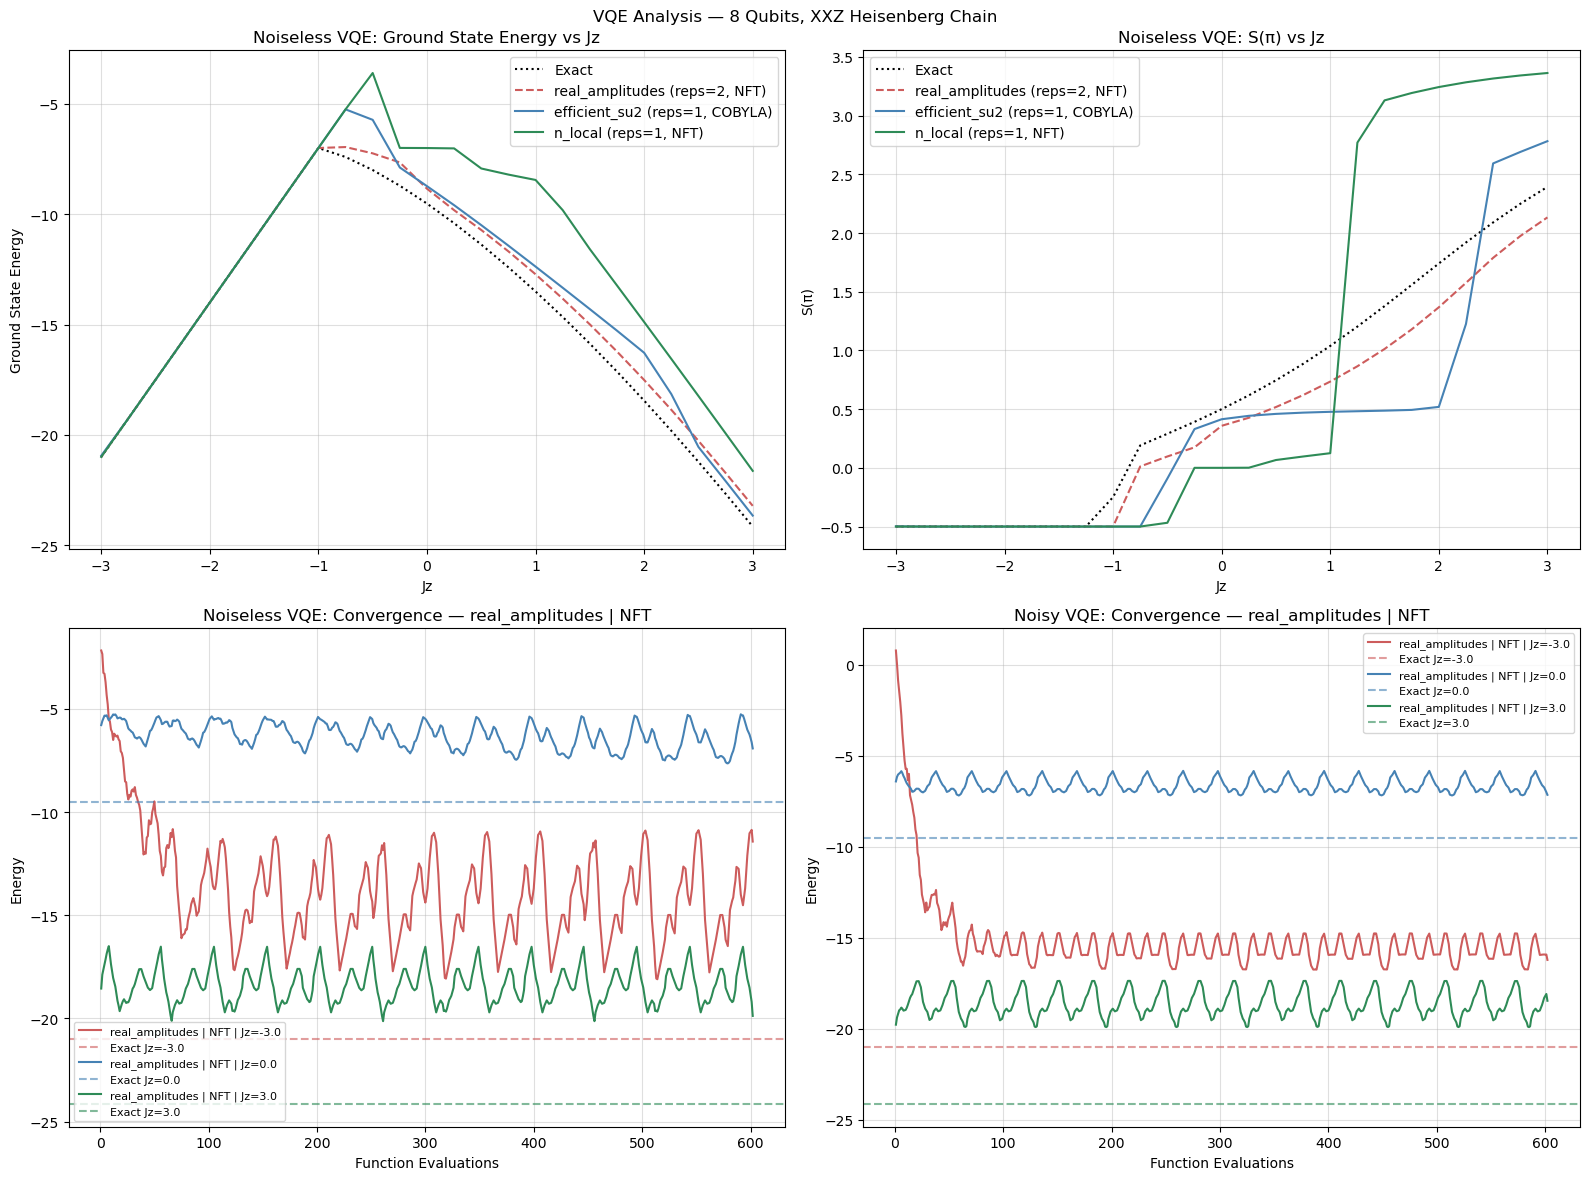

In [8]:
#----- Plot Analysis -----#

colors = {
    "efficient_su2": "steelblue",
    "real_amplitudes": "indianred",
    "n_local": "seagreen"
}

conv_colors = ["indianred", "steelblue", "seagreen"]
ls_reps = {1: "solid", 2: "dashed"}
target_jz = [-3.0, 0, 3.0]

#---- Noiseless Rankings -----#

# Best config per ansatz (needs full jz arrays)
best_noiseless = {}
for r in noiseless_ranked:
    key = r["ansatz_names"]
    if key not in best_noiseless or r["mean_abs_error"] < best_noiseless[key]["mean_abs_error"]:
        best_noiseless[key] = r


#----- Exact Diagonalization ----- #
jz_exact = list(np.arange(-3.0 , 3.0 + 0.125, 0.25))
s_pi_mat = np.array(s_pi_operator(n_qubits).to_matrix())
e0_exact, spi_exact_ref = [], []

for jz in jz_exact:
    e_gs, psi0 = exact_ground_state(heisenberg_hamiltonian(n_qubits, Jz=jz))
    e0_exact.append(e_gs)
    spi_exact_ref.append(float(np.real(psi0.conj() @ s_pi_mat @ psi0)))


#----- Convergence Plots ----- #

best_noiseless_r = min(noiseless_sweep_results, key=lambda r: r["mean_abs_error"])
best_noisy_r     = min([r for r in multiqubit_results if r["n_qubits"] == 8],
                        key=lambda r: r["mean_abs_error"])

noiseless_target_ks = [min(range(len(best_noiseless_r["jz_values"])),
                           key=lambda i: abs(best_noiseless_r["jz_values"][i] - t))
                       for t in target_jz]
noisy_target_ks     = [min(range(len(best_noisy_r["jz_values"])),
                           key=lambda i: abs(best_noisy_r["jz_values"][i] - t))
                       for t in target_jz]

#----- Plots -----#

plt.figure(figsize=(16,12))

# Ground State Energy vs Jz (noiseless) #

plt.subplot(2, 2, 1)
plt.plot(jz_exact, e0_exact, label="Exact", color="black", linestyle="dotted")
for name, r in best_noiseless.items():
    plt.plot(r["jz_values"], r["E_vqe"], label=f"{name} (reps={r['reps']}, {r['optimizer']})", color=colors[name], linestyle=ls_reps[r['reps']])
plt.xlabel ("Jz")
plt.ylabel("Ground State Energy")
plt.title("Noiseless VQE: Ground State Energy vs Jz")
plt.legend()
plt.grid(alpha = 0.4)
    
# Antiferromagnetic Order Parameter S(π) vs Jz (noiseless) #

plt.subplot(2, 2, 2)
plt.plot(jz_exact, spi_exact_ref, label="Exact", color="black", linestyle="dotted")
for name, r in best_noiseless.items():
    plt.plot(r["jz_values"], r["Spi_vqe"], label=f"{name} (reps={r['reps']}, {r['optimizer']})", color=colors[name], linestyle=ls_reps[r['reps']])
plt.xlabel("Jz")
plt.ylabel("S(π)")
plt.title("Noiseless VQE: S(π) vs Jz")
plt.legend()
plt.grid(alpha = 0.4)

# Noiseless Convergence
plt.subplot(2, 2, 3)
for k, color, t in zip(noiseless_target_ks, conv_colors, target_jz):
    values   = best_noiseless_r['conv_values'][k]
    smoothed = np.convolve(values, np.ones(10)/10, mode='valid')
    plt.plot(best_noiseless_r['conv_counts'][k][:len(smoothed)], smoothed,
             label=f"{best_noiseless_r['ansatz_names']} | {best_noiseless_r['optimizer']} | Jz={t:.1f}", color=color)
    exact_e = e0_exact[min(range(len(jz_exact)), key=lambda i: abs(jz_exact[i] - t))]
    plt.axhline(exact_e, color=color, linestyle='dashed', alpha=0.6, label=f"Exact Jz={t:.1f}")
plt.xlabel("Function Evaluations")
plt.ylabel("Energy")
plt.title(f"Noiseless VQE: Convergence — {best_noiseless_r['ansatz_names']} | {best_noiseless_r['optimizer']}")
plt.legend(fontsize=8)
plt.grid(alpha=0.4)

# Noisy Convergence
plt.subplot(2, 2, 4)
for k, color, t in zip(noisy_target_ks, conv_colors, target_jz):
    values   = best_noisy_r['conv_values'][k]
    smoothed = np.convolve(values, np.ones(10)/10, mode='valid')
    plt.plot(best_noisy_r['conv_counts'][k][:len(smoothed)], smoothed,
             label=f"{best_noisy_r['ansatz_names']} | {best_noisy_r['optimizer']} | Jz={t:.1f}", color=color)
    exact_e = e0_exact[min(range(len(jz_exact)), key=lambda i: abs(jz_exact[i] - t))]
    plt.axhline(exact_e, color=color, linestyle='dashed', alpha=0.6, label=f"Exact Jz={t:.1f}")
plt.xlabel("Function Evaluations")
plt.ylabel("Energy")
plt.title(f"Noisy VQE: Convergence — {best_noisy_r['ansatz_names']} | {best_noisy_r['optimizer']}")
plt.legend(fontsize=8)
plt.grid(alpha=0.4)

plt.suptitle(f"VQE Analysis — {n_qubits} Qubits, XXZ Heisenberg Chain")
plt.tight_layout()
plt.savefig("vqe_analysis_plots.png", dpi=150, bbox_inches="tight")
plt.show()